# Exercise for Graph 5

In [1]:
import random
from typing import TypedDict, List, Literal
from langgraph.graph import StateGraph, END

# 1. Define the State
# We match the input structure from the image and add 'secret_number'
# so the system knows what to check against.
class GameState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    # Internal state for game logic
    secret_number: int
    last_guess: int
    status: str  # To track if we won or lost

# 2. Define the Nodes

def setup_node(state: GameState):
    """Initializes the secret number if not present."""
    print("--- SETUP GAME ---")
    # If a secret number wasn't provided, pick a random one between 1-20
    secret = state.get("secret_number")
    if secret is None:
        secret = random.randint(1, 20)

    print(f"Secret Number (Shhh!): {secret}")
    return {"secret_number": secret, "attempts": 0, "status": "playing"}

def guess_node(state: GameState):
    """Calculates the next guess based on current bounds."""
    low = state["lower_bound"]
    high = state["upper_bound"]

    # Simple Binary Search Strategy: Pick the midpoint
    # This guarantees we find the number efficiently.
    guess = (low + high) // 2

    # Ensure we don't get stuck if bounds cross (sanity check)
    if guess < low: guess = low
    if guess > high: guess = high

    print(f"Agent guesses: {guess}")

    return {
        "last_guess": guess,
        "guesses": state["guesses"] + [guess],
        "attempts": state["attempts"] + 1
    }

def hint_node(state: GameState):
    """
    Acts as the 'Game Master'.
    Checks the guess and updates the bounds (Higher/Lower) for the next turn.
    """
    guess = state["last_guess"]
    secret = state["secret_number"]

    # Check for win
    if guess == secret:
        print(f"--- CORRECT! The number was {secret} ---")
        return {"status": "won"}

    # Provide Hint & Adjust Bounds
    updates = {}
    if guess < secret:
        print(f"Hint: Higher than {guess}")
        # The number is higher, so our new lower bound is guess + 1
        updates["lower_bound"] = guess + 1
    else:
        print(f"Hint: Lower than {guess}")
        # The number is lower, so our new upper bound is guess - 1
        updates["upper_bound"] = guess - 1

    return updates

# 3. Define Conditional Logic
def should_continue(state: GameState) -> Literal["guess", END]:
    """Decides if the game loop continues or stops."""
    if state["status"] == "won":
        return END

    if state["attempts"] >= 7:
        print("--- GAME OVER: Max attempts reached ---")
        return END

    return "guess"

# 4. Build the Graph
workflow = StateGraph(GameState)

# Add nodes
workflow.add_node("setup", setup_node)
workflow.add_node("guess", guess_node)
workflow.add_node("hint", hint_node)

# Add edges
# Start -> Setup -> Guess
workflow.set_entry_point("setup")
workflow.add_edge("setup", "guess")

# Guess -> Hint
workflow.add_edge("guess", "hint")

# Hint -> Conditional (Loop back to Guess OR End)
workflow.add_conditional_edges(
    "hint",
    should_continue,
    {
        "guess": "guess",
        END: END
    }
)

# Compile
app = workflow.compile()

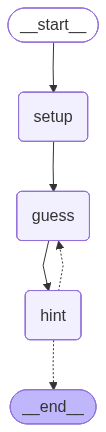

In [3]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
# 5. Run the Graph (Example)
inputs = {
    "player_name": "Student",
    "guesses": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20
}

# Invoke the app
result = app.invoke(inputs)

--- SETUP GAME ---
Secret Number (Shhh!): 3
Agent guesses: 10
Hint: Lower than 10
Agent guesses: 5
Hint: Lower than 5
Agent guesses: 2
Hint: Higher than 2
Agent guesses: 3
--- CORRECT! The number was 3 ---
